# Naive Bayes Classifier

## Objective

- Understand the principles of Naive Bayes classification.
- Learn Bayes' Theorem and the independence assumption.
- Implement Gaussian Naive Bayes from scratch using NumPy.
- Build a Naive Bayes classifier using Scikit-learn.
- Evaluate classification performance using appropriate metrics.
- Compare scratch implementation with Scikit-learn results.

# Dataset Information

**Dataset Name:** Breast Cancer Wisconsin Dataset

**Kaggle Link:**  
https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset

**Reason for Selection:**  
This real-world healthcare dataset is widely used for binary classification tasks and is well-suited for demonstrating Gaussian Naive Bayes using continuous clinical features.

**Target Variable:** `diagnosis`

- M → Malignant
- B → Benign

**Credits:** Kaggle

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.naive_bayes import GaussianNB

In [2]:
# Load dataset
df = pd.read_csv("dataset/breast-cancer.csv")

# Display first 5 rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Dataset Exploration

Before training the Naive Bayes model, we explore the dataset structure, identify the target variable, and check for missing values.

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDiagnosis Distribution:")
print(df['diagnosis'].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (569, 32)

Column Names:
['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Diagnosis Distribution:
diagnosis
B    357
M    212
Name: count, dtype: int64

Missing Values:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Data Preprocessing

The `id` column is removed since it does not contribute to prediction. The target variable is encoded into numerical values, and the dataset is split into training and testing sets.

In [4]:
# Remove unnecessary column
df = df.drop('id', axis=1)

# Encode target variable
df['diagnosis'] = df['diagnosis'].map({
    'M': 1,
    'B': 0
})

# Features
X = df.drop('diagnosis', axis=1)

# Target
y = df['diagnosis']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (455, 30)
Testing Feature Shape: (114, 30)
Training Target Shape: (455,)
Testing Target Shape: (114,)


## Gaussian Naive Bayes: From Scratch (NumPy)

In this section, we implement Gaussian Naive Bayes from scratch using NumPy. This helps understand how class priors, means, variances, and probability calculations work internally.

In [5]:
# Convert to NumPy arrays
X_train_np = X_train.values
X_test_np = X_test.values

y_train_np = y_train.values
y_test_np = y_test.values

In [6]:
classes = np.unique(y_train_np)

means = {}
variances = {}
priors = {}

for c in classes:

    X_c = X_train_np[y_train_np == c]

    means[c] = X_c.mean(axis=0)

    variances[c] = X_c.var(axis=0) + 1e-9

    priors[c] = len(X_c) / len(X_train_np)

print("Class Priors:")
print(priors)

Class Priors:
{np.int64(0): 0.6263736263736264, np.int64(1): 0.37362637362637363}


In [7]:
def gaussian_log_probability(x, mean, variance):

    return -0.5 * np.sum(
        np.log(2 * np.pi * variance)
        + ((x - mean) ** 2) / variance
    )

In [8]:
def predict_naive_bayes(X):

    predictions = []

    for x in X:

        posteriors = {}

        for c in classes:

            prior = np.log(priors[c])

            likelihood = gaussian_log_probability(
                x,
                means[c],
                variances[c]
            )

            posteriors[c] = prior + likelihood

        predictions.append(
            max(posteriors, key=posteriors.get)
        )

    return np.array(predictions)

In [9]:
scratch_predictions = predict_naive_bayes(X_test_np)

scratch_accuracy = accuracy_score(
    y_test_np,
    scratch_predictions
)

print("Scratch Implementation Accuracy:",
      round(scratch_accuracy, 4))

Scratch Implementation Accuracy: 0.9211


## Gaussian Naive Bayes using Scikit-learn

Scikit-learn provides an optimized implementation of Gaussian Naive Bayes suitable for continuous features.

In [10]:
model = GaussianNB()

model.fit(X_train, y_train)

print("Gaussian Naive Bayes model trained successfully!")

Gaussian Naive Bayes model trained successfully!


## Model Evaluation

After training the model, we evaluate its performance using accuracy, confusion matrix, and classification metrics.

In [11]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy Score:",
      round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred
))

Accuracy Score: 0.9386

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        72
           1       1.00      0.83      0.91        42

    accuracy                           0.94       114
   macro avg       0.96      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



## Confusion Matrix

The confusion matrix summarizes the model's prediction performance by comparing actual and predicted class labels.

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[72  0]
 [ 7 35]]


## Diagnosis Distribution

This visualization shows the distribution of malignant and benign cases in the dataset.

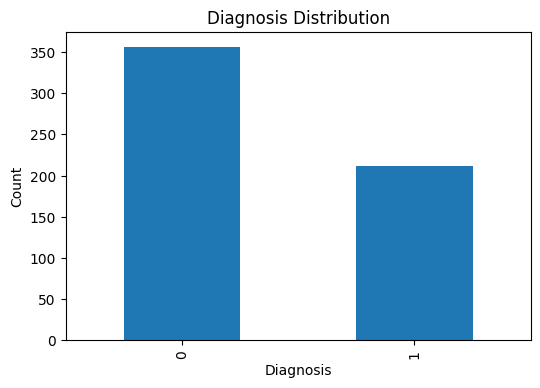

In [13]:
plt.figure(figsize=(6, 4))

df['diagnosis'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Diagnosis Distribution'
)

plt.xlabel(
    'Diagnosis'
)

plt.ylabel(
    'Count'
)

plt.show()

## Hyperparameter Experiment

Gaussian Naive Bayes uses the `var_smoothing` parameter to improve numerical stability. Here, we experiment with different values and observe their effect on model performance.

In [14]:
var_values = [1e-12, 1e-9, 1e-6]

for value in var_values:

    experiment_model = GaussianNB(
        var_smoothing=value
    )

    experiment_model.fit(
        X_train,
        y_train
    )

    predictions = experiment_model.predict(
        X_test
    )

    score = accuracy_score(
        y_test,
        predictions
    )

    print(
        f"var_smoothing = {value}: Accuracy = {score:.4f}"
    )

var_smoothing = 1e-12: Accuracy = 0.9211
var_smoothing = 1e-09: Accuracy = 0.9386
var_smoothing = 1e-06: Accuracy = 0.9035


## Interview Corner

### Question:
Why does Naive Bayes perform well even though the independence assumption is often violated?

### Answer:
Naive Bayes focuses on identifying the class with the highest posterior probability rather than estimating exact probabilities. Even when features are correlated, the ranking of posterior probabilities often remains correct, resulting in strong classification performance.

## Bayes' Theorem

Posterior ∝ Likelihood × Prior

Where:

- Prior = Initial belief about the class.
- Likelihood = Probability of observing the features given the class.
- Posterior = Updated belief after considering the evidence.

### Significance

Bayes' Theorem forms the mathematical foundation of Naive Bayes by combining prior knowledge with observed evidence to make predictions.

## Key Takeaways

1. Naive Bayes is a probabilistic supervised learning algorithm used for classification tasks.
2. Gaussian Naive Bayes is suitable for continuous numerical features.
3. The independence assumption simplifies probability estimation and enables fast computation.
4. Both NumPy and Scikit-learn implementations help build conceptual understanding.
5. Evaluation metrics such as accuracy, precision, recall, and F1-score provide insights into model performance.
6. Hyperparameter tuning can improve numerical stability and predictive performance.
7. Real-world healthcare datasets make learning more practical and meaningful.

## Workflow Diagram

![Naive Bayes Workflow](images/workflow.png)